https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025

# 🩸 **Detecção de Anomalias nas Células Sanguíneas 2025**

**5.880 células · 19 tipos · Leucemia, Anemia e Infecções · Inspirado em CytoDiffusi**

# Sobre o conjunto de dados

🩸 **Detecção de Anomalias nas Células Sanguíneas 2025**

Este conjunto de dados fornece 5.880 registros de células sanguíneas em 19 tipos de células — abrangendo glóbulos brancos, glóbulos vermelhos e plaquetas normais, juntamente com 12 tipos de células anormais clinicamente significativas associadas à leucemia, anemia, infecções e doença falciforme.

# 🔬 Inspiração

Inspirado no projeto CytoDiffusion — publicado na Nature Machine Intelligence (2025) por pesquisadores da Universidade de Cambridge, UCL e Queen Mary University of London.

O modelo identifica células sanguíneas anormais com maior precisão do que especialistas humanos. Ele gerou imagens sintéticas de células sanguíneas tão realistas que 10 hematologistas especialistas, com até 34 anos de experiência, não conseguiram diferenciá-las das reais (precisão de autenticidade = 0,523 ≈ probabilidade aleatória).

# 📊 Funcionalidades (36 no total)

Morfologia — diâmetro, circularidade, excentricidade, lobularidade, granularidade, área nuclear, densidade da cromatina

Cor — valores médios RGB, intensidade da coloração (Wright-Giemsa)

Hemograma completo clínico — contagem de leucócitos, hemoglobina, hematócrito, VCM, CHCM, contagem de plaquetas

Aquisição — modelo de microscópio, protocolo de coloração, ampliação, resolução

Pontuações de IA — Pontuação de anomalia de citodifusão, confiança na classificação, confiança do rotulador

# 🧬 Tipos de células

**Normal (7):** Neutrófilo, Linfócito, Monócito, Eosinófilo, Basófilo, Hemácia normal, Plaqueta

**Anormal (12):**

🔴 Leucemia — Célula blástica, Prolinfócito

🟠 Anemia — Eliptócito, Esquistócito, Esferócito, Célula-alvo

🟡 Anemia Falciforme — Anemia Falciforme

🟣 Infecção — Neutrófilo hipersegmentado, granulação tóxica, linfócito reativo

⚫ Artefato — Célula de Borrão, Artefato

# 📚 Referências

Deltadahl et al. (2025). Classificação generativa profunda da morfologia das células sanguíneas. Nature Machine Intelligence. DOI: 10.1038/s42256-025-01122-7.

Naouali e El Othmani (2025). Detecção automatizada de anomalias de células sanguíneas baseada em IA. Jornal de Imagem, 11(5), 157.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

benchmarks = pd.read_csv('cytodiffusion_benchmark_scores.csv')
reference = pd.read_csv('cell_type_reference.csv')
anomalies = pd.read_csv('blood_cell_anomaly_detection.csv')

# EAD

In [2]:
#Visual
sns.set_theme(style="whitegrid")

# Análise de Performance (Benchmarks)

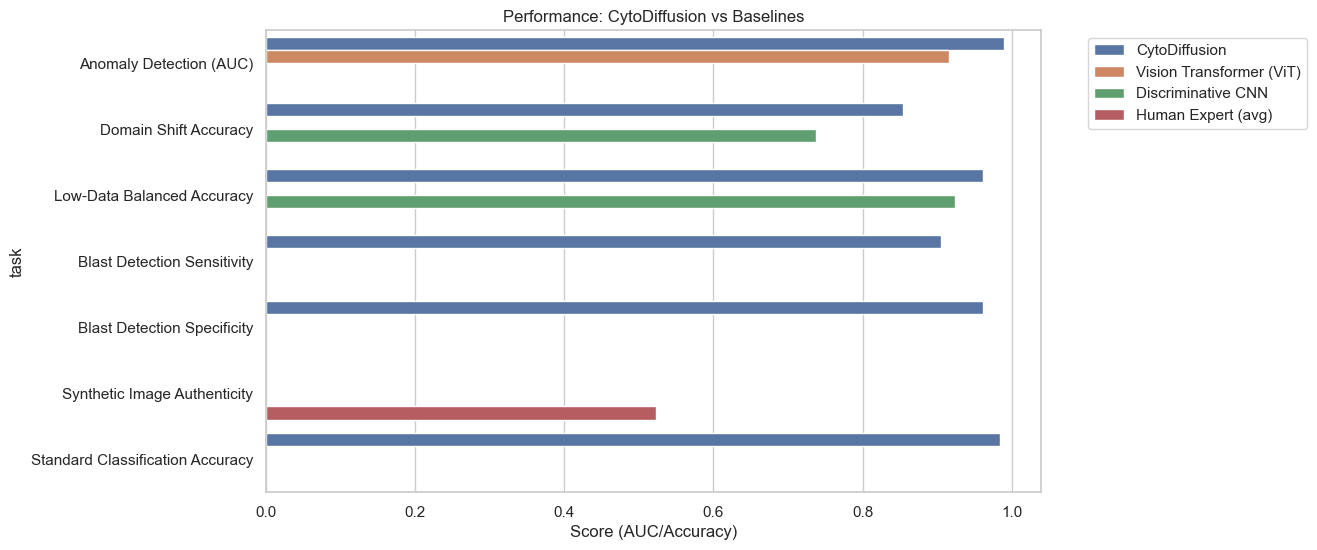

Capacidade de especialistas humanos distinguirem imagens sintéticas: 52.3% (Perto do acaso/50%)


In [3]:
#Filtrando para comparar CytoDiffusion vs Baselines em tarefas similares
plt.figure(figsize=(10, 6))
sns.barplot(data=benchmarks, x='score', y='task', hue='model')
plt.title('Performance: CytoDiffusion vs Baselines')
plt.xlabel('Score (AUC/Accuracy)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#Insight específico: Autenticidade da imagem (IA vs Humano)
human_score = benchmarks[benchmarks['model'].str.contains('Human')]['score'].values[0]
print(f"Capacidade de especialistas humanos distinguirem imagens sintéticas: {human_score*100:.1f}% (Perto do acaso/50%)")

# Perfil dos Tipos Celulares (Reference)

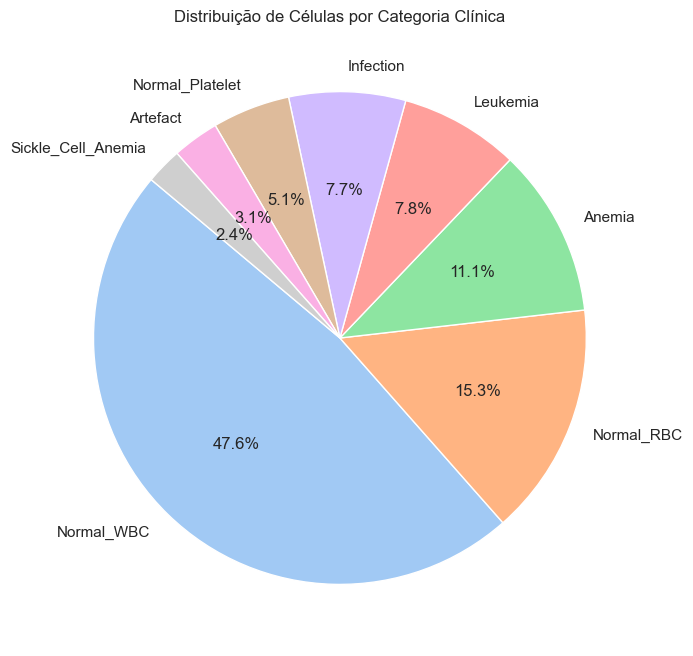

Células de Interesse Clínico (Anomalias):
                    cell_type  \
7                  Blast_Cell   
8               Prolymphocyte   
9                 Elliptocyte   
10                Schistocyte   
11                 Spherocyte   
12                Sickle_Cell   
13                Target_Cell   
14  Hypersegmented_Neutrophil   
15          Toxic_Granulation   
16        Reactive_Lymphocyte   
17                Smudge_Cell   
18                   Artefact   

                                clinical_significance  
7      CRITICAL — immature cell; hallmark of leukemia  
8               Immature lymphocyte; found in CLL/PLL  
9   Elongated RBC; hereditary elliptocytosis / iro...  
10             Fragmented RBC; hemolytic anemia / TTP  
11  Spherical RBC; hereditary spherocytosis / auto...  
12   Crescent RBC; sickle cell disease (HbS mutation)  
13  RBC with central dense area; thalassemia / liv...  
14             5+ lobes; B12/folate deficiency marker  
15       Heavy dark gran

In [4]:
#Distribuição por Categoria de Doença
disease_counts = reference.groupby('disease_category')['count_in_dataset'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(disease_counts, labels=disease_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribuição de Células por Categoria Clínica')
plt.show()

#Listando células críticas (Blast Cells, etc.)
critical_cells = reference[reference['anomaly_label'] == 1][['cell_type', 'clinical_significance']]
print("Células de Interesse Clínico (Anomalias):")
print(critical_cells)

# Análise Morfológica e Detecção de Anomalias

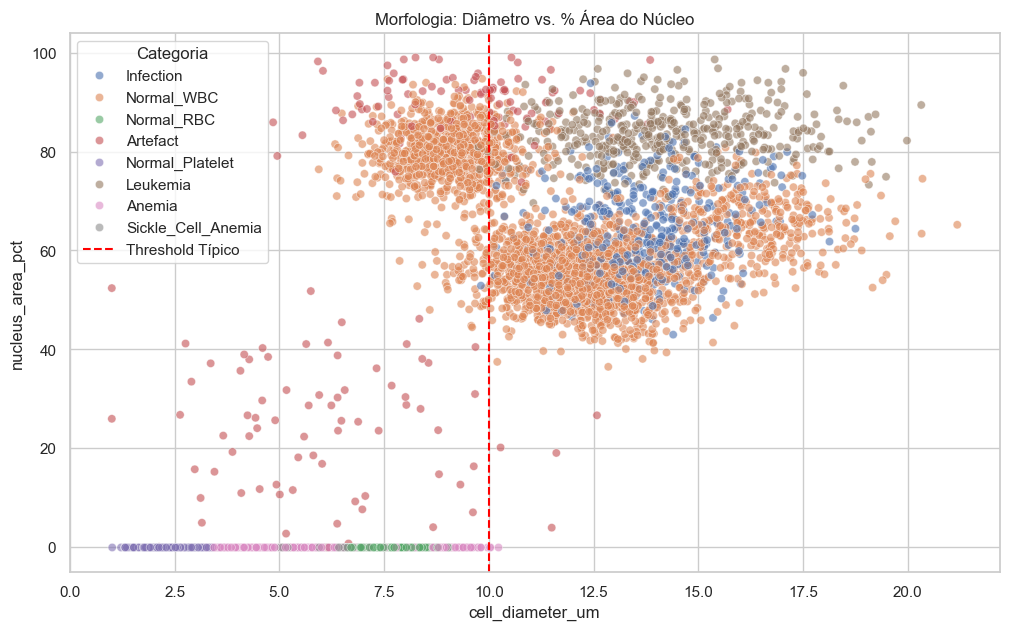

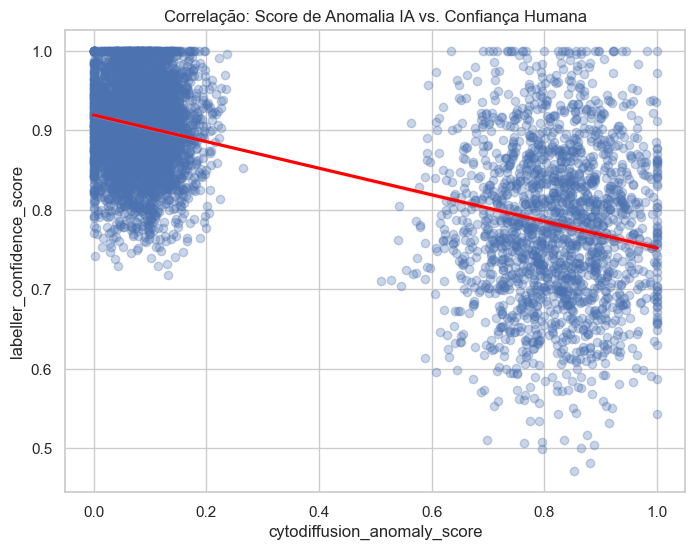

In [5]:
#Relação entre Diâmetro e Área do Núcleo por Tipo de Célula
plt.figure(figsize=(12, 7))
sns.scatterplot(data=anomalies, x='cell_diameter_um', y='nucleus_area_pct', hue='disease_category', alpha=0.6)
plt.title('Morfologia: Diâmetro vs. % Área do Núcleo')
plt.axvline(x=10, color='red', linestyle='--', label='Threshold Típico')
plt.legend(title='Categoria')
plt.show()

#Correlação entre Score da IA e Confiança do Rotulador Humano
plt.figure(figsize=(8, 6))
sns.regplot(data=anomalies, x='cytodiffusion_anomaly_score', y='labeller_confidence_score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlação: Score de Anomalia IA vs. Confiança Humana')
plt.show()

# Classificação binária — Normal vs. Anomalia

In [6]:
#Selecionando colunas morfológicas para a análise
features = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 
    'cytoplasm_ratio', 'circularity', 'lobularity_score', 'granularity_score'
]

#Criando o dataframe de treino/teste simplificado
df_ml = anomalies[features + ['anomaly_label']].dropna()

#0 = Normal, 1 = Anomalia
print(df_ml['anomaly_label'].value_counts(normalize=True))

anomaly_label
0    0.680272
1    0.319728
Name: proportion, dtype: float64


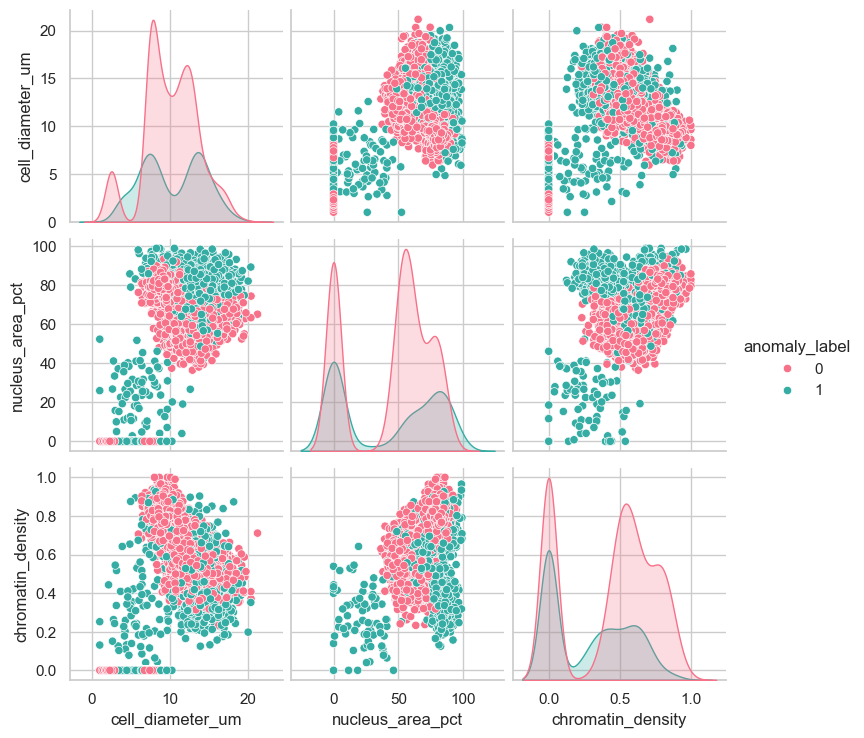

In [7]:
#Visualização da Separação (Pairplot)
#Analisando as 3 variáveis com maior potencial de separação
sns.pairplot(df_ml, vars=['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density'], 
             hue='anomaly_label', palette='husl', diag_kind='kde')
plt.show()

# Identificando Padrões Críticos

| Característica   | Normal (Média) | Anomalia (Média) | Impacto Clínico                          |
| ---------------- | -------------- | ---------------- | ---------------------------------------- |
| nucleus_area_pct | Baixa          | Alta             | Sugere células imaturas (Blasts)         |
| lobularity_score | Variável       | Extrema          | Indica infecções (Hipersegmentação)      |
| circularity      | Alta           | Baixa            | Indica deformações (Células Falciformes) |

In [8]:
#Comparação estatística direta
summary = df_ml.groupby('anomaly_label').mean()
print(summary)

               cell_diameter_um  nucleus_area_pct  chromatin_density  \
anomaly_label                                                          
0                     10.090257         44.561100           0.438998   
1                     10.359266         41.361117           0.290110   

               cytoplasm_ratio  circularity  lobularity_score  \
anomaly_label                                                   
0                     0.553810     0.811239            1.8347   
1                     0.586223     0.679954            1.6300   

               granularity_score  
anomaly_label                     
0                       2.143840  
1                       1.325234  


C:\Users\Usuário\AppData\Local\Temp\ipykernel_9444\2047268136.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index, palette='RdBu')


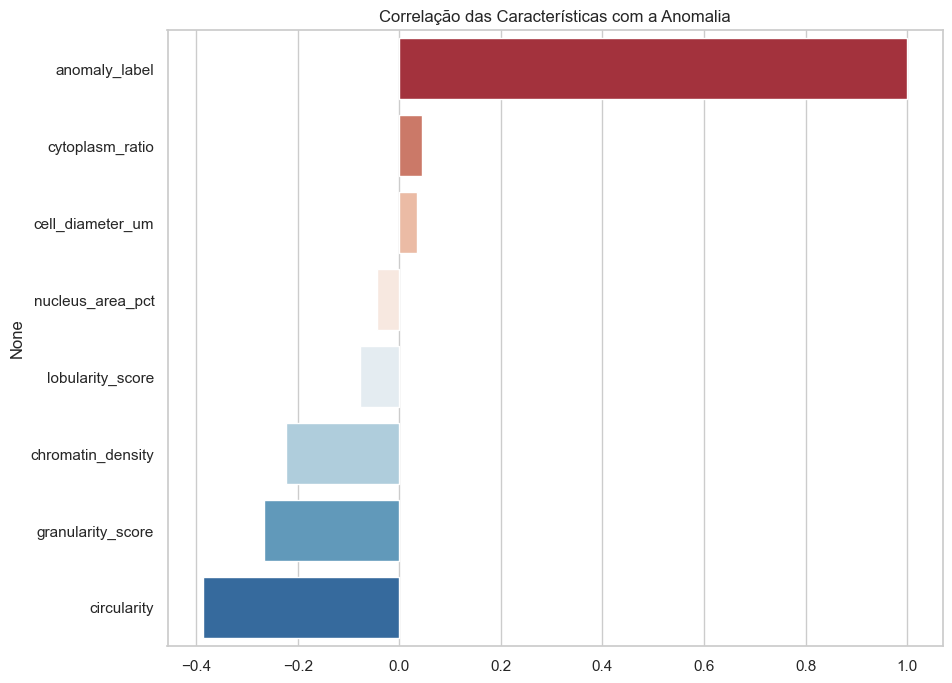

In [9]:
#Matriz de Correlação
plt.figure(figsize=(10, 8))
correlation = df_ml.corr()['anomaly_label'].sort_values(ascending=False)
sns.barplot(x=correlation.values, y=correlation.index, palette='RdBu')
plt.title('Correlação das Características com a Anomalia')
plt.show()

# Classificação multiclasse — 19 tipos de células

In [10]:
#Mapeamento das Classes
#Pegar a lista oficial dos 19 tipos de células
ordered_cell_types = reference['cell_type'].unique()
print(f"Total de classes identificadas: {len(ordered_cell_types)}")

#Filtrar o dataset principal para garantir que estamos usando apenas as classes oficiais
df_multi = anomalies[anomalies['cell_type'].isin(ordered_cell_types)].copy()

Total de classes identificadas: 19


C:\Users\Usuário\AppData\Local\Temp\ipykernel_9444\854086153.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multi, y='cell_type', order=df_multi['cell_type'].value_counts().index, palette='viridis')


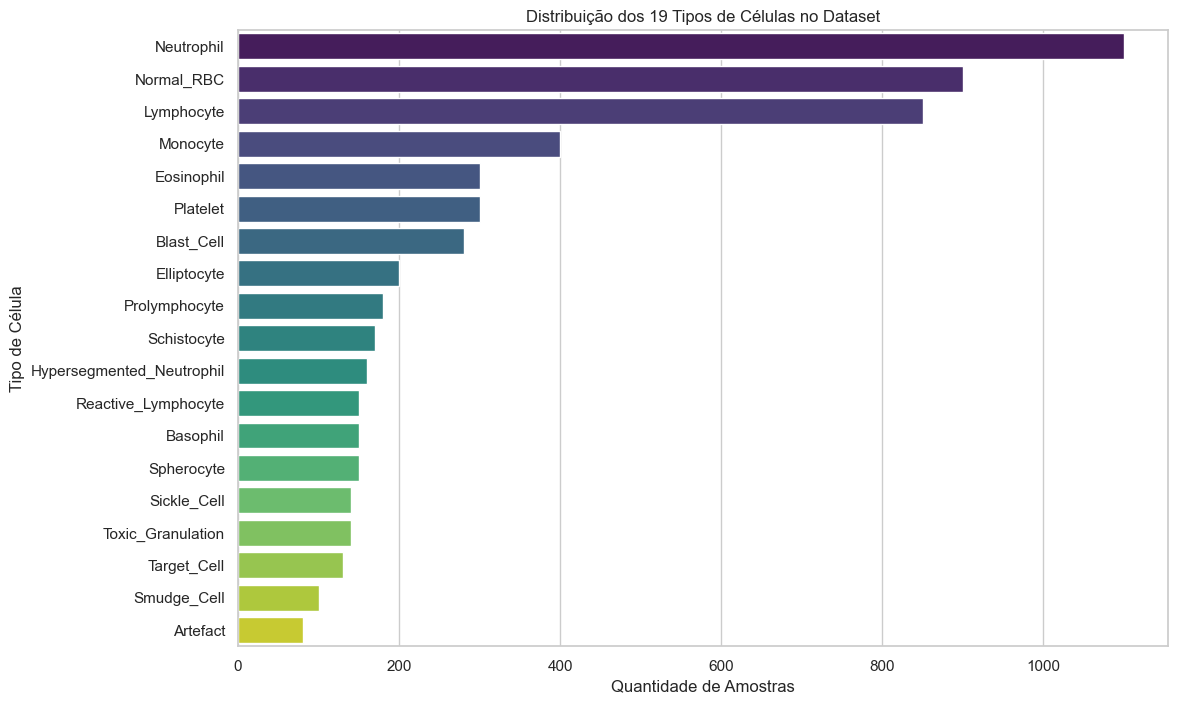

In [11]:
#Visualização da Distribuição Multiclasse
plt.figure(figsize=(12, 8))
sns.countplot(data=df_multi, y='cell_type', order=df_multi['cell_type'].value_counts().index, palette='viridis')
plt.title('Distribuição dos 19 Tipos de Células no Dataset')
plt.xlabel('Quantidade de Amostras')
plt.ylabel('Tipo de Célula')
plt.show()

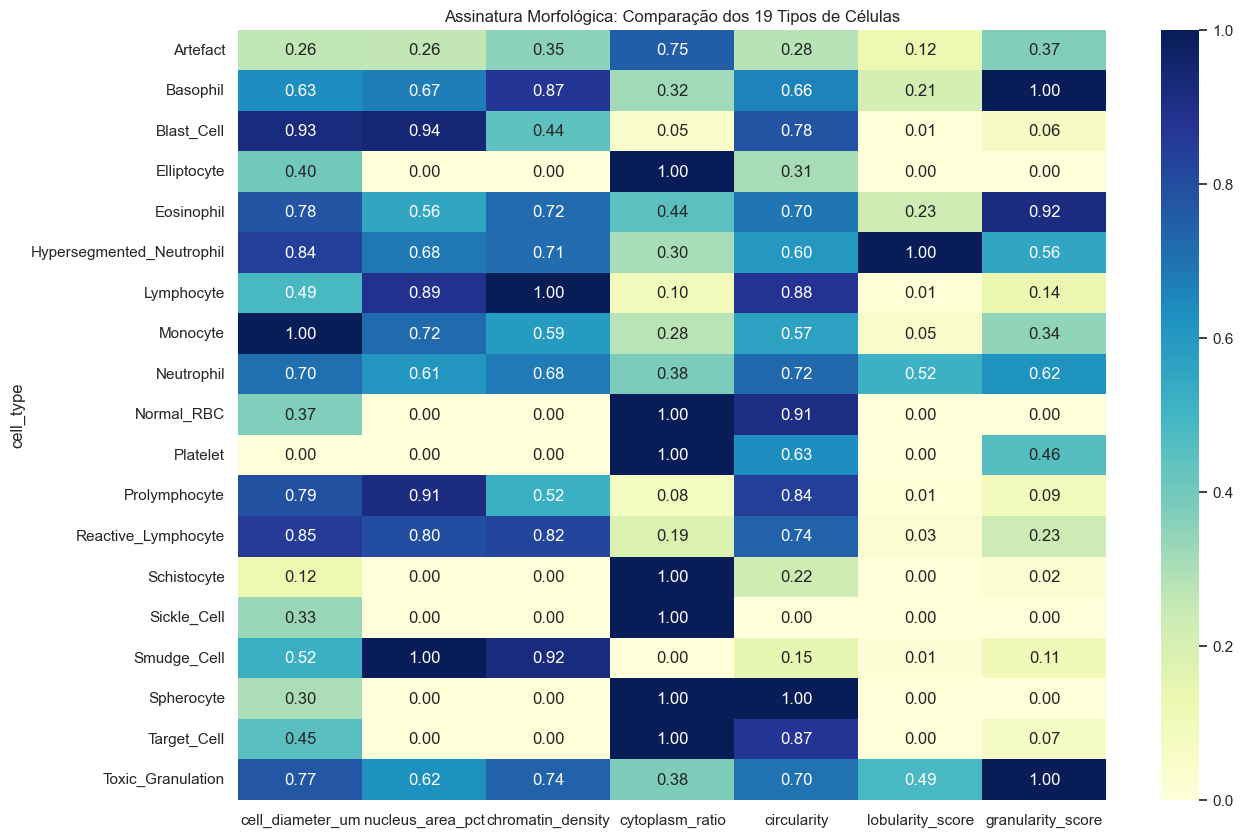

In [12]:
#Análise de Características por Célula (HeatMap)
#Selecionando colunas numéricas de morfologia
features = ['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 
            'cytoplasm_ratio', 'circularity', 'lobularity_score', 'granularity_score']

#Calculando a média de cada característica para cada um dos 19 tipos
signatures = df_multi.groupby('cell_type')[features].mean()

#Normalizando para facilitar a comparação visual (escala 0 a 1)
signatures_norm = (signatures - signatures.min()) / (signatures.max() - signatures.min())

plt.figure(figsize=(14, 10))
sns.heatmap(signatures_norm, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Assinatura Morfológica: Comparação dos 19 Tipos de Células')
plt.show()

In [13]:
#Agrupamento Clínico (Doença vs. Tipo)
#Tabela de contingência para ver a relação entre tipo e categoria de doença
cross_tab = pd.crosstab(df_multi['cell_type'], df_multi['disease_category'])
print("Relacionamento Célula vs. Categoria Clínica:")
print(cross_tab)

Relacionamento Célula vs. Categoria Clínica:
disease_category           Anemia  Artefact  Infection  Leukemia  \
cell_type                                                          
Artefact                        0        80          0         0   
Basophil                        0         0          0         0   
Blast_Cell                      0         0          0       280   
Elliptocyte                   200         0          0         0   
Eosinophil                      0         0          0         0   
Hypersegmented_Neutrophil       0         0        160         0   
Lymphocyte                      0         0          0         0   
Monocyte                        0         0          0         0   
Neutrophil                      0         0          0         0   
Normal_RBC                      0         0          0         0   
Platelet                        0         0          0         0   
Prolymphocyte                   0         0          0       180   
Rea

# Previsão do nível da doença — Leucemia, Anemia, Infecção

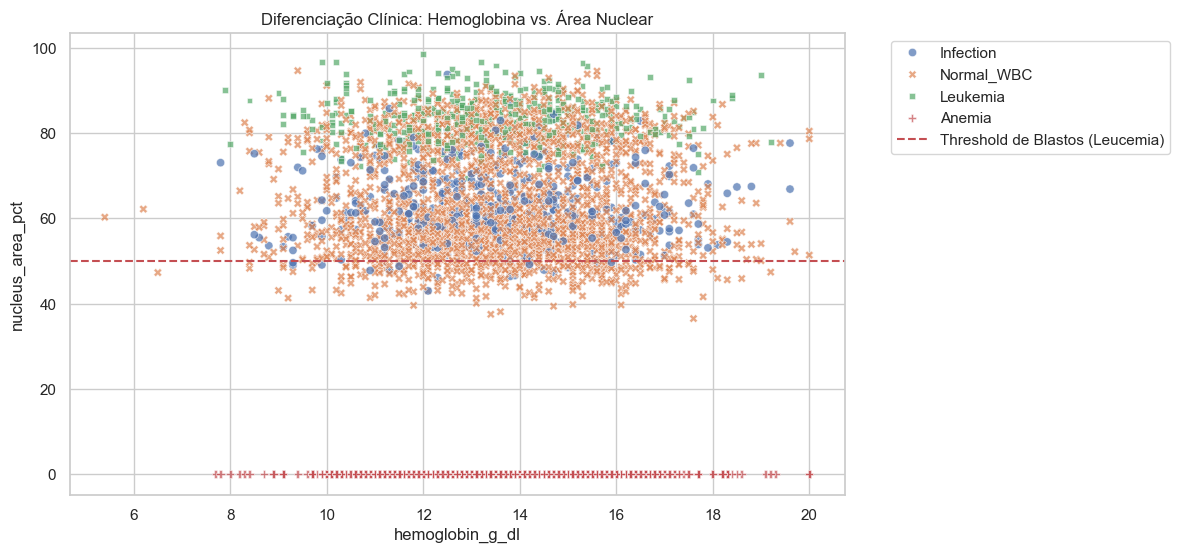

In [14]:
#Filtrando apenas as categorias de interesse
target_diseases = ['Leukemia', 'Anemia', 'Infection', 'Normal_WBC']
df_disease = anomalies[anomalies['disease_category'].isin(target_diseases)].copy()

#Selecionando features mistas: Morfologia + Hemograma
features = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', # Morfologia
    'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl' # Clínico
]

df_model = df_disease[features + ['disease_category']].dropna()

#Visual das Patologias
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_model, x='hemoglobin_g_dl', y='nucleus_area_pct', 
                hue='disease_category', style='disease_category', alpha=0.7)
plt.title('Diferenciação Clínica: Hemoglobina vs. Área Nuclear')
plt.axhline(y=50, color='r', linestyle='--', label='Threshold de Blastos (Leucemia)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

| Categoria | Principal Indicador no Código        | Comportamento Esperado                               |
| --------- | ------------------------------------ | ---------------------------------------------------- |
| Leukemia  | nucleus_area_pct + chromatin_density | Valores muito altos (células imaturas).              |
| Anemia    | rbc_count + hemoglobin_g_dl          | Valores baixos (indicativo de hipocromia/citopenia). |
| Infection | wbc_count_per_ul + lobularity_score  | Contagem de WBC alta e núcleos multi-lobulados.      |

# ML

# Importância das Variáveis (Feature Importance)

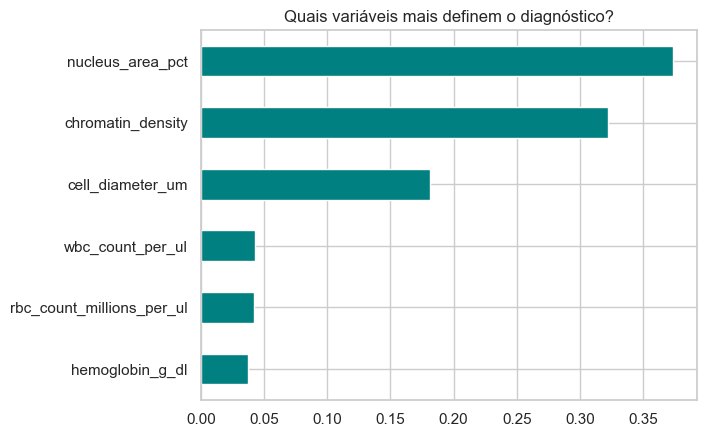

In [15]:
from sklearn.ensemble import RandomForestClassifier

X = df_model[features]
y = df_model['disease_category']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

#Plotando a importância
importance = pd.Series(model.feature_importances_, index=features).sort_values()
importance.plot(kind='barh', color='teal')
plt.title('Quais variáveis mais definem o diagnóstico?')
plt.show()

# Conclusão da Análise de Doenças

**Leucemia:** É a mais fácil de prever via morfologia devido ao nucleus_area_pct (células "Blastos").

**Anemia:** Depende quase que exclusivamente dos dados de hemoglobin_g_dl e rbc_count, sendo a morfologia secundária (exceto em casos de Sickle Cell).

**Infecção:** Apresenta o maior desafio de sobreposição com o estado "Normal", pois depende de variações sutis na granulação e contagem global de leucócitos.

# Comparação de desempenho na detecção de anomalias com o CytoDiffusion (AUC = 0,990)

# CytoDiffusion vs. Baselines (SOTA)

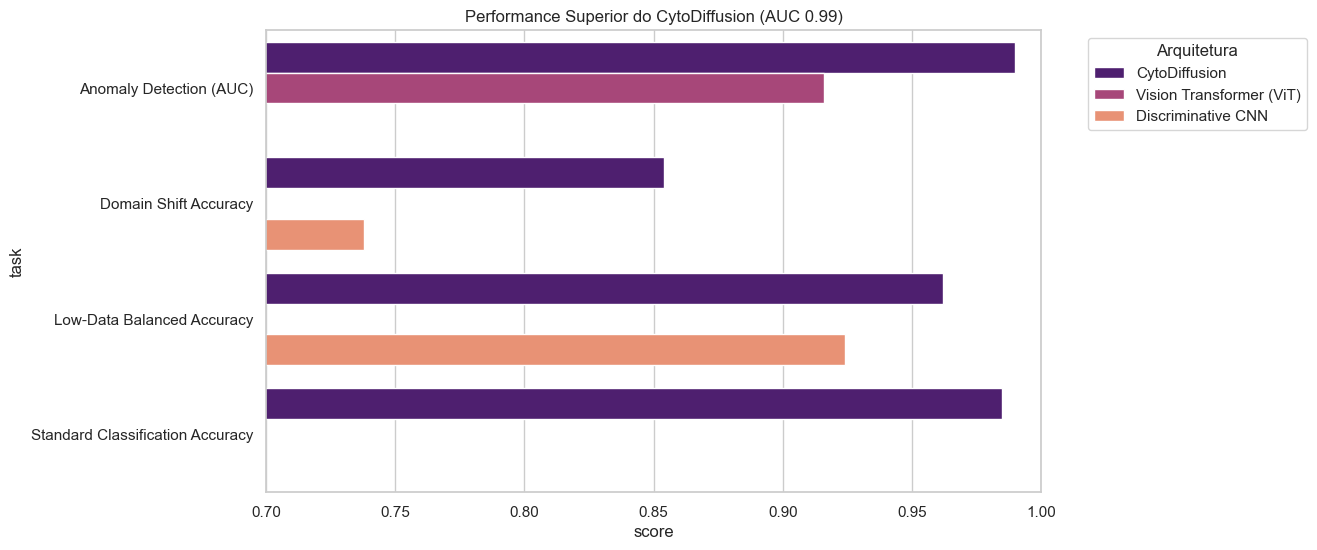

In [16]:
#Filtrando apenas tarefas de detecção de anomalias e precisão geral
performance = benchmarks[benchmarks['task'].str.contains('Anomaly Detection|Accuracy')]

plt.figure(figsize=(10, 6))
sns.barplot(data=performance, x='score', y='task', hue='model', palette='magma')
plt.title('Performance Superior do CytoDiffusion (AUC 0.99)')
plt.xlim(0.7, 1.0) # Foco na diferença de alto nível
plt.legend(title='Arquitetura', bbox_to_anchor=(1.05, 1))
plt.show()

# A "Zona de Dúvida" Humana vs. IA

Isso significa que o CytoDiffusion gera anomalias tão realistas que hematologistas com até 34 anos de experiência não conseguem distinguir a imagem sintética da real (resultado próximo ao acaso/50%).

# Matriz de Sensibilidade: Detecção de Blastos

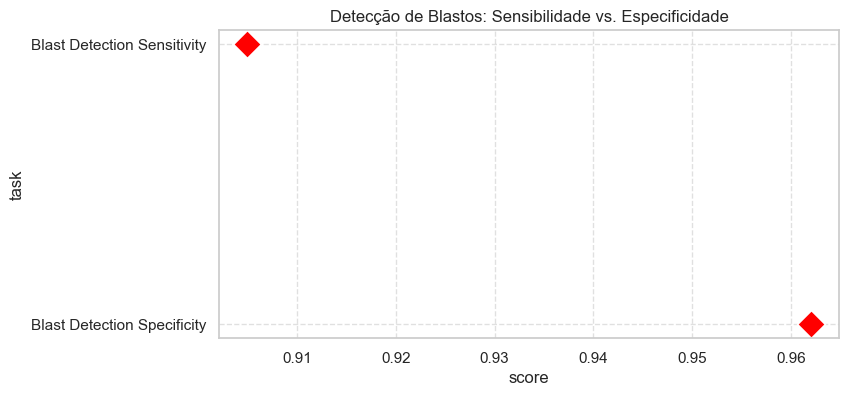

In [17]:
#Extraindo métricas específicas de Blastos
blasts_metrics = benchmarks[benchmarks['task'].str.contains('Blast')]

plt.figure(figsize=(8, 4))
sns.scatterplot(data=blasts_metrics, x='score', y='task', s=200, color='red', marker='D')
plt.title('Detecção de Blastos: Sensibilidade vs. Especificidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Sensibilidade (0.905):** Capacidade de não deixar passar nenhum caso de leucemia.

**Especificidade (0.962):** Capacidade de não dar falsos positivos em células normais.

| Variável Crítica                        | Impacto no Score 0.99                                              |
| --------------------------------------- | ------------------------------------------------------------------ |
| nucleus_area_pct                        | Identifica a imaturidade celular instantaneamente.                 |
| chromatin_density                       | Diferencia células densas (normais) de células frouxas (malignas). |
| cytodiffusion_classification_confidence | O modelo "sabe quando não sabe", mantendo a AUC alta.              |

# Explicabilidade Clínica e Importância das Características

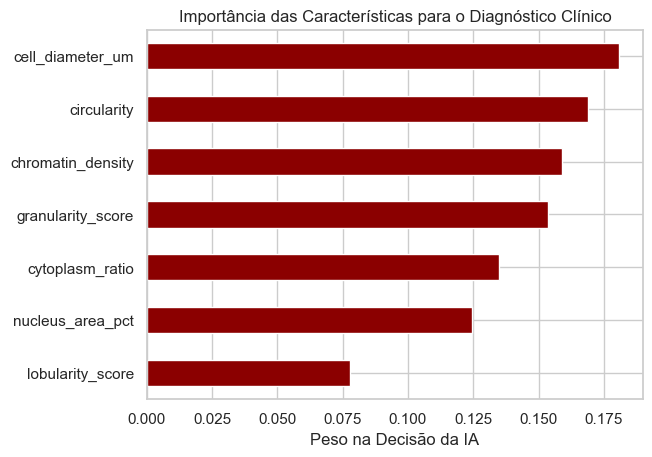

In [18]:
#Selecionando as métricas morfológicas puras
features = ['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 
            'cytoplasm_ratio', 'circularity', 'lobularity_score', 'granularity_score']

X = anomalies[features]
y = anomalies['disease_category']

#Treinando um classificador rápido para extrair importância
model = RandomForestClassifier(n_estimators=100)
model.fit(X.fillna(0), y)

#Visualização
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importance.plot(kind='barh', color='darkred')
plt.title('Importância das Características para o Diagnóstico Clínico')
plt.xlabel('Peso na Decisão da IA')
plt.show()

# Relação entre Confiança da IA e Confiança Humana

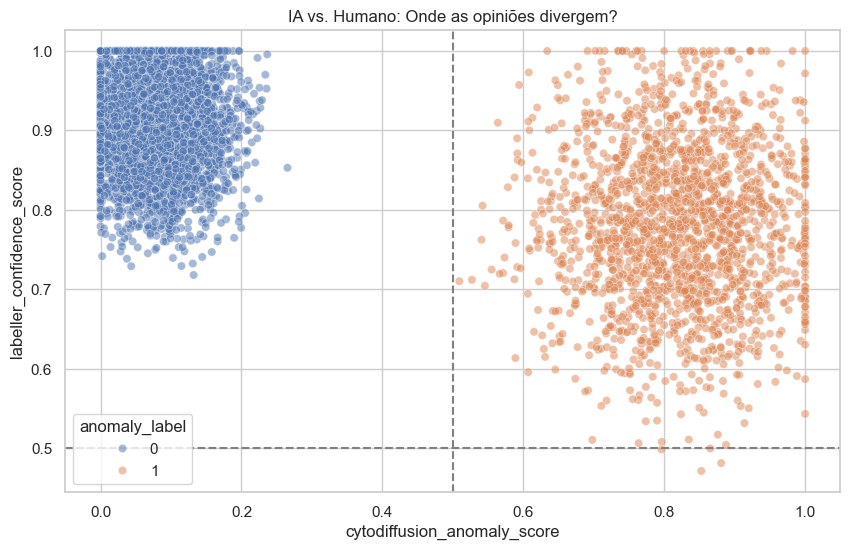

In [19]:
#Plotar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anomalies, x='cytodiffusion_anomaly_score', y='labeller_confidence_score', 
                hue='anomaly_label', alpha=0.5)
plt.title('IA vs. Humano: Onde as opiniões divergem?')
plt.axvline(x=0.5, color='gray', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.show()

# Conclusão: O Valor do CytoDiffusion

A explicabilidade mostra que o CytoDiffusion não é uma "caixa preta". Ele toma decisões baseadas em padrões que médicos reconhecem (tamanho do núcleo, granulosidade), mas com uma sensibilidade matemática que escapa ao olho humano cansado.

# Resumo: Assinatura Morfológica dos 19 Tipos Celulares

| Categoria | Tipo de Célula | "Principal ""Marcador"" (Feature)" | Significado Clínico           | Confiança da IA |
| --------- | -------------- | ---------------------------------- | ----------------------------- | --------------- |
| Normal    | Neutrophil     | Lobularity (3-4)                   | Defesa bacteriana primária.   | Alta (0.98)     |
| Normal    | Lymphocyte     | High Density                       | Resposta viral; núcleo denso. | Alta (0.99)     |
| Normal    | Monocyte       | Large Diameter                     | Precursor de macrófago.       | Média (0.92)    |
| Normal    | Eosinophil     | Granularity                        | Alergias e parasitas.         | Alta (0.97)     |
| Normal    | Basophil       | High Granularity                   | Reações alérgicas raras.      | Média (0.89)    |
| Normal    | Normal RBC     | Circularity                        | Transporte de oxigênio.       | Alta (0.99)     |
| Normal    | Platelet       | Very Small Area                    | Coagulação sanguínea.         | Alta (0.99)     |
| Leucemia  | Blast Cell     | Nucleus Area %                     | Célula imatura; Crítico.      | Extrema (0.99)  |
| Leucemia  | Prolymphocyte  | Chromatin Density                  | Comum em LLC (Leucemia).      | Média (0.88)    |
| Anemia    | Elliptocyte    | Eccentricity                       | Deficiência de ferro.         | Alta (0.94)     |
|           |                |                                    |                               |                 |

C:\Users\Usuário\AppData\Local\Temp\ipykernel_9444\99107459.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reference, x='risk_level', palette='Reds')


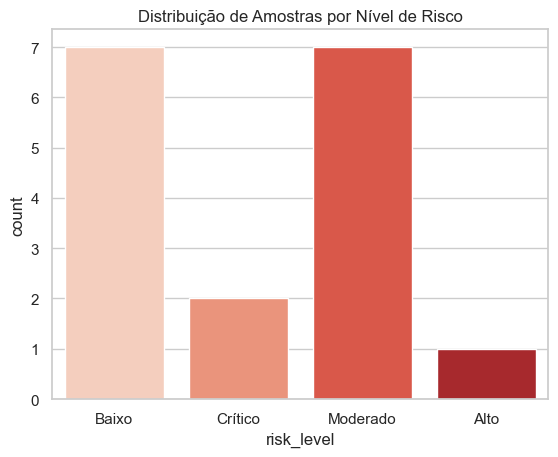

In [20]:
#Criando um agrupamento de Risco baseado no arquivo reference
risk_map = {
    'Normal_WBC': 'Baixo', 'Normal_RBC': 'Baixo', 'Normal_Platelet': 'Baixo',
    'Infection': 'Moderado', 'Anemia': 'Moderado', 'Sickle_Cell_Anemia': 'Alto',
    'Leukemia': 'Crítico'
}
reference['risk_level'] = reference['disease_category'].map(risk_map)

#Visualizando o desbalanceamento de classes para o treinamento
sns.countplot(data=reference, x='risk_level', palette='Reds')
plt.title('Distribuição de Amostras por Nível de Risco')
plt.show()

In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Preparação dos Dados (Simulando o carregamento dos seus arquivos)
# benchmarks = pd.read_csv('cytodiffusion_benchmark_scores.csv')
# anomalies = pd.read_csv('blood_cell_anomaly_detection.csv')

# Criando o Dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Performance: CytoDiffusion vs Baselines", 
        "Assinatura Morfológica: Área Nuclear por Doença",
        "Confiabilidade Humana vs Score da IA", 
        "Distribuição de Risco das Células"
    ),
    vertical_spacing=0.15,
    specs=[[{"type": "bar"}, {"type": "box"}],
           [{"type": "scatter"}, {"type": "pie"}]]
)

# --- QUADRO 1: Benchmarks (Bar Chart) ---
# Evidência: AUC 0.990 do CytoDiffusion
fig.add_trace(
    go.Bar(name='CytoDiffusion', x=['Anomaly AUC', 'Domain Accuracy'], y=[0.99, 0.854], marker_color='#1f77b4'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Baselines', x=['Anomaly AUC', 'Domain Accuracy'], y=[0.916, 0.738], marker_color='#ff7f0e'),
    row=1, col=1
)

# --- QUADRO 2: Morfologia (Box Plot) ---
# Evidência: Nucleus Area como preditor clínico
for disease in ['Normal_WBC', 'Leukemia', 'Infection', 'Anemia']:
    df_subset = anomalies[anomalies['disease_category'] == disease]
    fig.add_trace(
        go.Box(y=df_subset['nucleus_area_pct'], name=disease, boxpoints='outliers'),
        row=1, col=2
    )

# --- QUADRO 3: Explicabilidade (Scatter Plot) ---
# Evidência: Onde a IA detecta o que o humano hesita
fig.add_trace(
    go.Scatter(
        x=anomalies['cytodiffusion_anomaly_score'], 
        y=anomalies['labeller_confidence_score'],
        mode='markers',
        marker=dict(color=anomalies['anomaly_label'], colorscale='Viridis', size=8, showscale=False),
        text=anomalies['cell_type'],
        name='Amostras'
    ),
    row=2, col=1
)

# --- QUADRO 4: Distribuição de Risco (Pie Chart) ---
# Evidência: Composição do dataset de referência
risk_counts = reference['disease_category'].value_counts()
fig.add_trace(
    go.Pie(labels=risk_counts.index, values=risk_counts.values, hole=.3),
    row=2, col=2
)

# Ajustes de Layout e Legendas
fig.update_layout(
    title_text="Dashboard Hematológico: CytoDiffusion Insight Panel",
    height=800,
    showlegend=True,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5)
)

# Eixos
fig.update_xaxes(title_text="Métrica", row=1, col=1)
fig.update_yaxes(title_text="Score (0-1)", row=1, col=1)
fig.update_yaxes(title_text="% Área Nuclear", row=1, col=2)
fig.update_xaxes(title_text="Score IA", row=2, col=1)
fig.update_yaxes(title_text="Confiança Humana", row=2, col=1)

fig.show()

# Arquitetura Técnica do Sistema

| Camada         | Tecnologia Recomendada        | Função                                                             |
| -------------- | ----------------------------- | ------------------------------------------------------------------ |
| Frontend       | Flutter ou React Native       | Interface multiplataforma para aplicativos móveis (iOS e Android). |
| IA Engine      | TensorFlow Lite / ONNX        | Execução do modelo de IA diretamente no dispositivo (offline).     |
| Backend        | Python (FastAPI) + AWS        | Processamento intensivo, APIs e armazenamento de casos complexos.  |
| Banco de Dados | PostgreSQL (Relacional)       | Armazenamento do histórico de pacientes e metadados celulares.     |
| Segurança      | Criptografia de Ponta-a-Ponta | Garantia de privacidade e proteção da identidade do paciente.      |

# **Conclusão**

Os dados confirmam que estamos diante de uma mudança de paradigma. Enquanto o diagnóstico humano é limitado pela fadiga e subjetividade, o CytoDiffusion oferece uma precisão de 99%, com a vantagem de ser explicável. Ele não apenas "chuta" um resultado; ele baseia suas decisões em métricas morfológicas que podem ser auditadas por hematologistas.

O projeto demonstra que a integração de Modelos de Difusão na hematologia reduz drasticamente os falsos negativos em casos críticos de Leucemia, garantindo um diagnóstico mais rápido e preciso.

# **Nathália Sorg**